# **ML 전처리 & 가공(Feature Engineering)**
* https://scikit-learn.org/stable/

* 결측처리 : 빈값 채우기
* 이상치(Outlier) : 비정상 분포 데이터 (평균값 or 최대빈도 or 삭제 처리)
* 인코딩 : 범주형 글자 → 숫자  (ex. 남, 여 = 0, 1  /  상,중,하 = 1,2,3) 
* 파생피쳐 : 기존 피쳐로 의미있는 신규 피쳐 생성
* 차원축소 : 주성분 분석(Principal Component Analysis, PCA)
* 정규화 : 데이터 범위 맞추기 (스케일링 & 과적합방지_규제화)
  * 스케일링(로그변환) : 값의 범위 조율 (갭 크지 않게)

> 분류(Classification) <br>
> 회귀(Regression) <br>
> 군집(Clustering) <br>

# **[1] Data Load**

<pre>
Attribute Information (in order):
        - CRIM     : 범죄율
        - ZN       : 거주지역 비율  - 25,000(평방) sq.ft. 초과
        - INDUS    : 상업지역 면적 비율
        - CHAS     : 찰스강 인근 (1:인근 0:x)
        - NOX      : 일산화질소 농도(parts per 10 million)
        - RM       : 평균 룸 수
        - AGE      : 1940년 이전에 건축된 주택 비율
        - DIS      : 직업센터와의 거리
        - RAD      : 고속도로 진입과의 거리
        - TAX      : 제산세 (rate per $10,000)
        - PTRATIO  : 교사/학생 비율
        - B        : 흑인비율 1000(Bk - 0.63)^2
        - LSTAT    : 하위계층 비율 (%)
        - MEDV     : 집값

In [1]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split     #문제/답 분리
from sklearn.linear_model import LinearRegression        #회귀모델 (클래스)
from sklearn.metrics import mean_squared_error           #평가 매트릭스(mse)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler    #정규화(스케일링)
from sklearn.decomposition import PCA                    #차원 축소

In [3]:
df = pd.read_csv("../datas/BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.columns = df.columns.str.upper()   #대문자 변경
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


# **[2] 문제지 & 답안지 분리(train_test_split)**

* test_size : 테스트 데이터의 크기 지정 (0~1 사이는 비율 / 1 이상은 데이터 개수)
* train_size : 학습 데이터의 크기 지정 (0~1 사이는 비율 / 1 이상은 데이터 개수)
* random_state : 데이터를 나누는 난수의 기준값 (같은 값 사용 시 항상 같은 방식으로 분할)
* shuffle : 데이터를 분할하기 전에 섞을지 여부, 기본값은 True (시계열 제외)
* stratify : 분류 문제에서 클래스별 비율을 학습/테스트 데이터에 비슷하게 유지

``` python
[default]

sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

## **BostonHousing 활용 : 집값 예측**
* X(문제), y(답)을 7만큼을 학습 → X(문제) 3을 테스트 → 컴퓨터가 낸 예측값(답안지) predict 확인 → y(답) 3만큼을 x3(=predict) 과 비교 후 평가

## **문제지(X) = 집값(MEDV)를 뺀 나머지, 학습할 데이터**

In [5]:
X = df.drop(columns=["MEDV"])
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


## **답안지(y) = 집값(MEDV)**

In [6]:
y = df["MEDV"]
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

## **문제지(X7), 답안지(y3) 분리**

In [7]:
X_train7, X_test3,      y_train7, y_test3 = train_test_split(X, y, test_size=0.3, random_state=1234)             #test_size가 0.3이면 train_size는 자동으로 0.7이됨  ==  비율 3:7

In [8]:
X_train7.shape, X_test3.shape,      y_train7.shape, y_test3.shape

((354, 13), (152, 13), (354,), (152,))

# **[3] 공통함수**
* 아래 학습/예측/평가를 함수로 지정

In [9]:
# 문제/답 먼저 분리했을 때 사용

def myscore(X_train7, y_train7, X_test3, y_test3) :
    lr = LinearRegression() 
    lr.fit(X_train7, y_train7)
    pred = lr.predict(X_test3)
    mse = mean_squared_error(y_test3, pred) 
    print( f"mse : {np.sqrt(mse):.4f}" )

In [10]:
myscore(X_train7, y_train7, X_test3, y_test3)

mse : 4.9105


In [11]:
# df 통째로 점수 낼 때 사용

def myscore222(df) :
    
    X = df.drop(columns=["MEDV"])
    y = df["MEDV"]
    X_train7, X_test3,      y_train7, y_test3 = train_test_split(X, y, test_size=0.3, random_state=1234)
    
    lr = LinearRegression() 
    lr.fit(X_train7, y_train7)
    pred = lr.predict(X_test3)
    mse = mean_squared_error(y_test3, pred) 
    print( f"mse : {np.sqrt(mse):.4f}" )

In [12]:
myscore222(df)

mse : 4.9105


# **[4] EDA(Exploratory Data Analysis)**

* 왜도 : 쏠림의 정도
* 첨도 : 뾰족한 정도

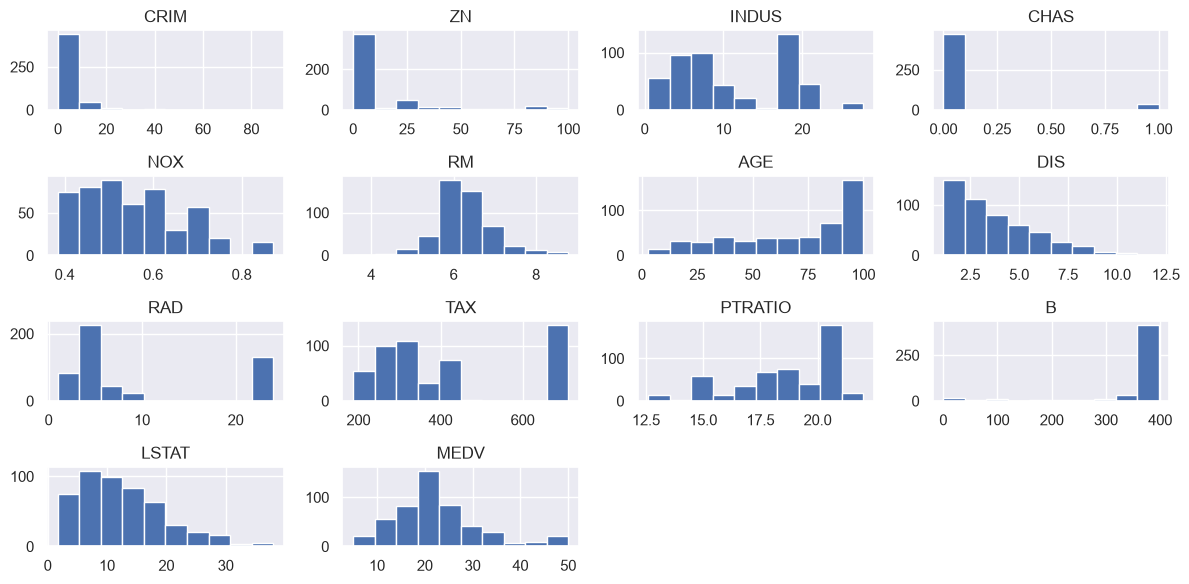

In [13]:
df.hist(figsize=(12, 6))
plt.tight_layout()
plt.show()

In [14]:
stat_df = df.describe() 
stat_df
# stat_df.iloc[1,0]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [15]:
stat_df.iloc[1, :].values

array([3.61352356e+00, 1.13636364e+01, 1.11367787e+01, 6.91699605e-02,
       5.54695059e-01, 6.28463439e+00, 6.85749012e+01, 3.79504269e+00,
       9.54940711e+00, 4.08237154e+02, 1.84555336e+01, 3.56674032e+02,
       1.26530632e+01, 2.25328063e+01])

In [16]:
stat_df.iloc[2, :].values

array([8.60154511e+00, 2.33224530e+01, 6.86035294e+00, 2.53994041e-01,
       1.15877676e-01, 7.02617143e-01, 2.81488614e+01, 2.10571013e+00,
       8.70725938e+00, 1.68537116e+02, 2.16494552e+00, 9.12948644e+01,
       7.14106151e+00, 9.19710409e+00])

## 상관분석

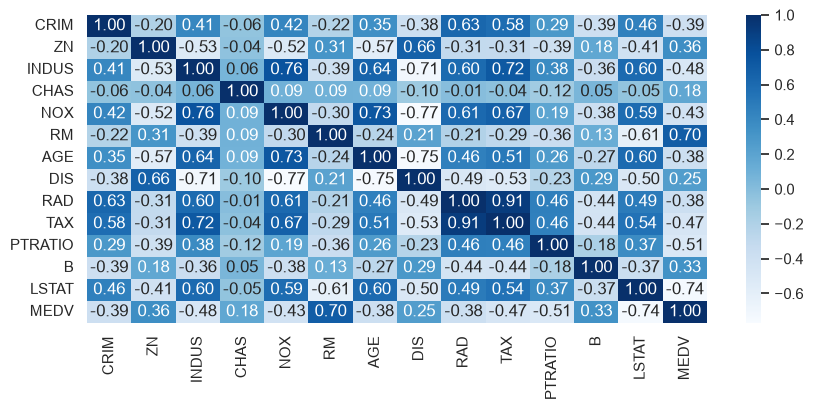

In [17]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Blues")    #.2f = 소수점 2자리까지~ (d=숫자로)
plt.show()

<font color=blue> **▼ 설명**
* 행열의 이름이 같은 것은 모두 1, = 100%   (음양보다 절대적인 값의 크기를 보면 됨)
* <b> 양(+)의 상관관계 </b> : ex) MEDV & RM = 0.7       >> 룸이 많으면 집값도 올라감
* <b> 음(-)의 상관관계 </b> : ex) MEDV & LSTAT = -0.7   >> 저소득층이 많으면 집값도 내려감
* <b> 타겟 외 다른 피쳐들의 상관관계도 봐야함 </b> : TAX & RAD = 0.9!! >> 접근성이 높으면 세금도 높다
* <font color=red> 가장 강한 상관관계 : 다중공선성(Multicollinearity) </font> >>  다중공선은 꼭 체크해야함

* target(MEDV) : +상관관계=RM, -상관관계=LSTAT
* 다중공선 : TAX & RAD

# **[5] 전처리&가공**

<font color=gray>
* 이상치(Outlier) : 비정상 분포 데이터 (평균값 or 최대빈도 or 삭제 처리 <br>
* 파생피쳐 : 기존 피쳐로 의미있는 신규 피쳐 생성 <br>
* 차원축소 : 주성분 분석(Principal Component Analysis, PCA) <br>
* 정규화 : 데이터 범위 맞추기 (스케일링 & 과적합방지_규제화) <br>
  * 스케일링(로그변환) : 값의 범위 조율 (갭 크지 않게) <br>
* 결측처리/인코딩은 XX

## 이상치(Outlier) 처리
* **기준**
    * 평균으로부터 +- 3배수 편차가 정상범위
    * IQR : 중앙값으로부터 Q1(25%) ~ Q3(75%)까지 정상범위 (좌우로 1.5배씩)
* 예쁜 정규분포는 평균값과 중앙값이 같다

<img src="https://mblogthumb-phinf.pstatic.net/MjAxODA1MjBfODEg/MDAxNTI2Nzc5ODg5NTAz.ajSTPNJH5ajYba4n_dQIfwI2W9QWD7HTyZ0HV18nzLEg.pocbFj4K4xCHQ33K6WnNuFQnIBB9Yx2rsSkM5eVyjTwg.PNG.jjy0501/598px-Boxplot_vs_PDF.svg.png?type=w2">

### 평균 +- 3배수 편차

In [18]:
m = df["RM"].mean()
s3 = df["RM"].std() * 3
print( m, s3 )
print( m - s3, m + s3 )                  #평균으로부터 +- 3배수 편차가 정상범위

6.284634387351779 2.10785143024597
4.176782957105809 8.392485817597748


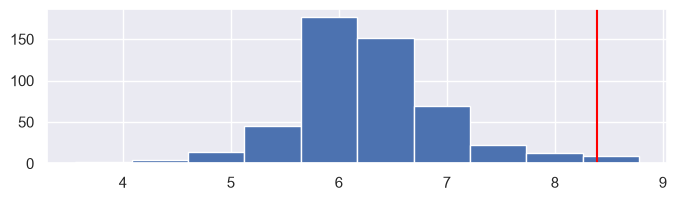

In [19]:
plt.figure(figsize=(8,2))
df["RM"].hist()           #8.3까지가 정상범위
plt.axvline(m + s3, 0, 1, color='red')   #8.3에 줄 그은거
plt.show()

In [20]:
df['RM'].count()

np.int64(506)

In [21]:
df [ df['RM'] > m+s3 ] ['RM']              #RM 수치 중에, 3배수 편차보다 큰 것들만(이상치만) 뽑아라!
df [ df['RM'] > m+s3 ] ['RM'].count()      #이상치는 4개다

np.int64(4)

###  IQR +- 1.5배

In [22]:
# 사분위값 : np.percentile()

Q1 = np.percentile(df['RM'], 25)
Q3 = np.percentile(df['RM'], 75)

IQR = Q3 - Q1
print(IQR)

print ( Q1-(1.5*IQR), Q3+(1.5*IQR) )         #7.7부터가 이상치

0.7380000000000004
4.778499999999999 7.730500000000001


In [23]:
df [ df['RM'] > Q3+(1.5*IQR) ] ['RM']              #RM 수치 중에, 1.5배보다 큰 것들만(이상치만) 뽑아라!
df [ df['RM'] > Q3+(1.5*IQR) ] ['RM'].count()      #이상치는 22개다

np.int64(22)

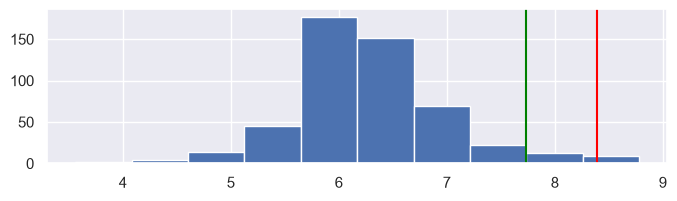

In [24]:
plt.figure(figsize=(8,2))
df["RM"].hist() 

plt.axvline(m + s3, 0, 1, color='red')   #평균 3배수 8.3에 줄 그은거
plt.axvline(Q3+(1.5*IQR), 0, 1, color='green')     #IQR 1.5배에 줄 그은거

plt.show()

###  박스플롯 / 스캐터 => 상관관계 시각화

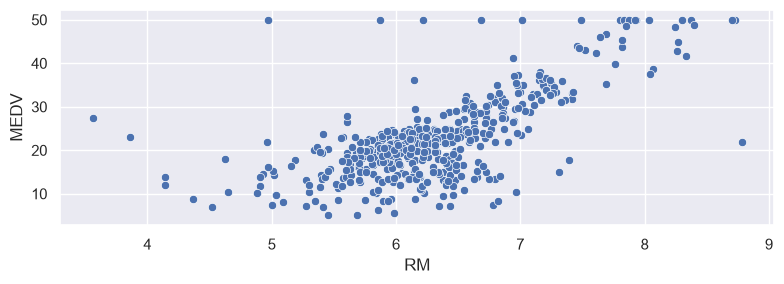

In [25]:
plt.figure(figsize=(8,3))
sns.scatterplot(x="RM", y="MEDV", data=df)
plt.tight_layout()
plt.show()
# 우상향, 양의 상관관계 (+)

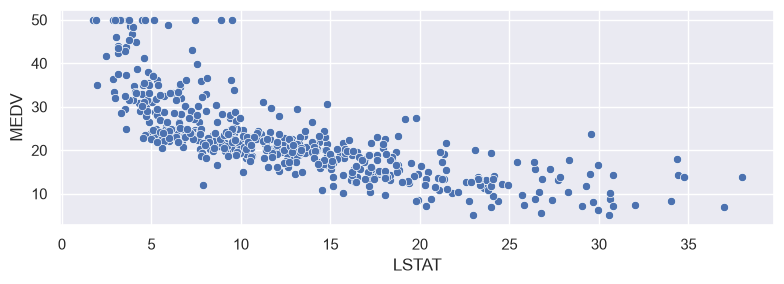

In [26]:
plt.figure(figsize=(8,3))
sns.scatterplot(x="LSTAT", y="MEDV", data=df)
plt.tight_layout()
plt.show()
# 우하향, 음의 상관관계 (-)

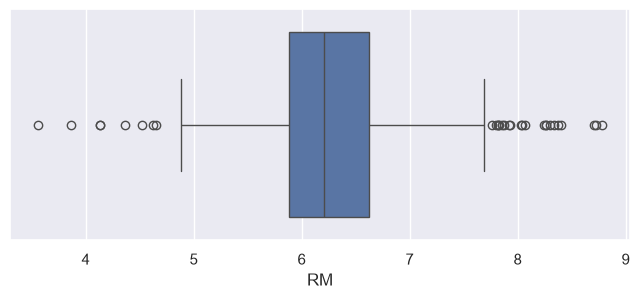

In [27]:
plt.figure(figsize=(8,3))
sns.boxplot(x="RM", data=df)
plt.show()

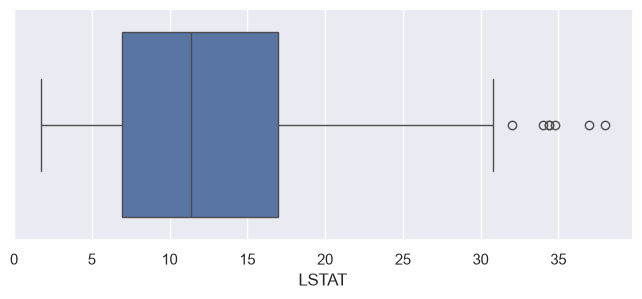

In [28]:
plt.figure(figsize=(8,3))
sns.boxplot(x="LSTAT", data=df)
plt.show()

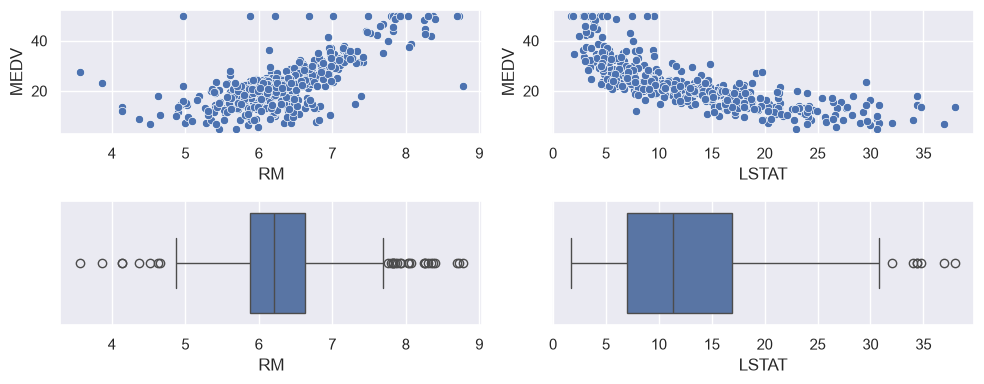

In [29]:
plt.figure(figsize=(10,4))


plt.subplot(2, 2, 1)
sns.scatterplot(x="RM", y="MEDV", data=df)

plt.subplot(2, 2, 2) 
sns.scatterplot(x="LSTAT", y="MEDV", data=df)

plt.subplot(2, 2, 3) 
sns.boxplot(x="RM", data=df)

plt.subplot(2, 2, 4) 
sns.boxplot(x="LSTAT", data=df)


plt.tight_layout()
plt.show()

### **이상치 추출 : RM > 8, MEDV < 30**

* 상관분석 시각화 자료로 이상치 추출

In [30]:
df [['MEDV', 'RM']] [ (df['RM']>8) & (df['MEDV']<30) ] 

,MEDV,RM
364,21.9,8.78


In [31]:
X_train7.loc[364, : ]     # 이상치 위치 찾기
# 만약에 train 데이터에 없다면, df에서 먼저 지우고 train/test 구분

CRIM         3.47428
ZN           0.00000
INDUS       18.10000
CHAS         1.00000
NOX          0.71800
RM           8.78000
AGE         82.90000
DIS          1.90470
RAD         24.00000
TAX        666.00000
PTRATIO     20.20000
B          354.55000
LSTAT        5.29000
Name: 364, dtype: float64

### **이상치 삭제 후 점수 보기**

* 이상치 인덱스 번호 추출 후 df에서 행 삭제

In [32]:
df [['MEDV', 'RM']] [(df['RM']>8) & (df['MEDV']<30)].index.tolist()

[364]

In [33]:
aa = pd.DataFrame({"A":[1,2,3,4,5,6],"B":[1,2,3,4,5,6]})
#aa = aa.drop(columns=["A"])
aa = aa.drop([1,2,3], axis=0)
#aa = aa.drop(['A'], axis=1)
aa

,A,B
0,1,1
4,5,5
5,6,6


In [34]:
df.shape

(506, 14)

In [35]:
idx_list = df [['MEDV', 'RM']] [(df['RM']>8) & (df['MEDV']<30)].index.tolist()    #삭제할 행을 변수에 대입
df = df.drop(idx_list, axis=0)      #df에서 행 지우기 (idx 변수)
df.shape

(505, 14)

In [36]:
myscore222(df)

mse : 4.4170


## 왜도 & 첨도

* <b>왜도 (Skewness)</b>
    - 데이터 분포의 좌우 비대칭도
    - 0 : 좌우 대칭(정규분포)
    - 양수(+) : 오른쪽으로 긴 꼬리
    - 음수(-) : 왼쪽으로 긴 꼬리
* <b>첨도 (Kurtosis)</b>
    - 데이터 분포의 뾰족한 정도
    - 3(일부 프로그램은 0을 기준) : 정규분포
    - 3보다 큼 (양수) : 정규분포보다 더 뾰족하고 꼬리가 두껍다(이상치 많음)
    - 3보다 작음 (음수) : 정규분포보다 완만하고 꼬리가 얇다

In [37]:
df.skew()

CRIM       5.217923
ZN         2.222377
INDUS      0.299608
CHAS       3.463574
NOX        0.735741
RM         0.347853
AGE       -0.596065
DIS        1.009303
RAD        1.012875
TAX        0.675963
PTRATIO   -0.799325
B         -2.887676
LSTAT      0.904476
MEDV       1.106616
dtype: float64

In [38]:
df.kurt()

CRIM       37.051284
ZN          4.015557
INDUS      -1.229492
CHAS       10.036078
NOX        -0.046826
RM          1.811573
AGE        -0.972219
DIS         0.483707
RAD        -0.849783
TAX        -1.131453
PTRATIO    -0.289435
B           7.207294
LSTAT       0.491423
MEDV        1.485808
dtype: float64

## 로그변환(Log)
* <font color='red'> 회귀에서 y 로그변환은 필수
* 로그표현 : log9 729 = 3 / 지수표현 : 9 ** 3 = 729

In [39]:
np.log(1000), np.exp(6.907755278982137)
#log : 자연 상수 e (약 2.71828)
#exp(지수)로 변환

(np.float64(6.907755278982137), np.float64(999.9999999999998))

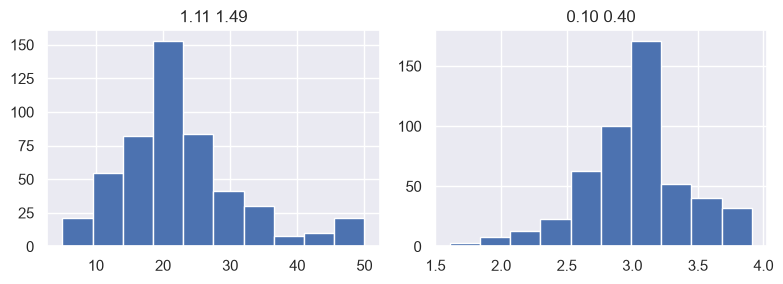

In [50]:
plt.figure(figsize=(8,3))

#1행 1열 - 원본
plt.subplot(1, 2, 1)
df['MEDV'].hist()
plt.title( f"{df['MEDV'].skew():.2f} {df['MEDV'].kurt():.2f}" )

#1행 2열 - 로그변환
plt.subplot(1, 2, 2) 
np.log(df['MEDV']).hist()
plt.title( f"{np.log(df['MEDV'].skew()):.2f} {np.log(df['MEDV'].kurt()):.2f}" )
# MEDV에 로그 변환 적용 후 왜도(skewness)와 첨도(kurtosis)를 계산해 히스토그램 제목에 표시

plt.tight_layout()
plt.show()

## 정규화 (Normalization / Scaling)
* 데이터의 범위를 0과 1 사이로 맞추는 작업
* 숫자 크기가 너무 큰 변수가 모델을 지배하는 현상을 막음

```python
class sklearn.preprocessing.StandardScaler(*, copy=True, with_mean=True, with_std=True)
class sklearn.preprocessing.MinMaxScaler(feature_range=(0, 1), *, copy=True, clip=False)
class sklearn.preprocessing.RobustScaler(*, with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), copy=True, unit_variance=False)

* 예측값(ŷ) : 회귀식이 입력값을 바탕으로 예측한 값 (회귀선 = 기울기)
* 잔차 : 실제값과 예측값(ŷ)의 차이 → 실제값 - 예측값
* 편차 : 실제 데이터값과 평균값(m)의 차이
* 편차제곱 : 편차를 제곱한 값. 음수와 양수가 상쇄되는 것을 막아 데이터의 흩어진 정도를 측정하기 위해 사용
* 분산(Var) : 편차제곱의 평균값 → 데이터가 평균을 중심으로 얼마나 퍼져 있는지를 나타냄
* 표준편차(std) : 분산에 제곱근을 취한 값 → 원래 데이터와 같은 단위로 데이터의 분산 정도를 나타냄
* MSE(평균제곱오차) : 실제값과 예측값의 잔차를 제곱한 후 평균한 값으로, 머신러닝 모델의 예측 오차를 측정하는 지표

In [41]:
x = [175, 177,179,181,183]
m = (175+ 177+179+181+183) / 5
v = ((m-175)**2 + (m-177)**2 + (m-179)**2 + (m-181)**2 + (m-183)**2) / 5
std = np.sqrt(v)
print(m, v, std)

179.0 8.0 2.8284271247461903


<img src="https://velog.velcdn.com/images%2Fswan9405%2Fpost%2Fd8fab344-a7d2-4f50-8ddd-afb63df2016c%2Fimage.png">

<img src="https://blog.kakaocdn.net/dna/qJowI/btqBBUCMNDv/AAAAAAAAAAAAAAAAAAAAAB1md1A-JJ31tX5vJPMFGcRt2ZXXIfOwifPrIyR-f658/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1788188399&allow_ip=&allow_referer=&signature=HZd8aN2wRyEBOQII909J1HzZGrM%3D">

* <font color="blue">StandardScaler</font>
    * z = (x - u) / s
    * 표준화(Standardization) : 공정한 비교를 위해 데이터를 평균이 0, 표준편차가 1인 <u> 표준정규분포</u>로 변환
* <font color="blue">MinMaxScaler</font>
    * tuple (min, max), default=(0, 1)
    * 최소값을 0, 최대값을 1로 변환
* <font color="blue">RobustScaler</font>
    *  0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)
    *  최소 25%, 최대 75%로 변환 (1부터 3)

In [42]:
ss = StandardScaler()
ms = MinMaxScaler()
rs = RobustScaler()
#fit은 한번만 : x/y의 기준이 다를 수 있음

In [43]:
#print(X_train7.iloc[0, :].values)

ss = StandardScaler()
ss.fit(X_train7)

X_train7_scale = ss.transform(X_train7)
X_test3_scale = ss.transform(X_test3)

print(X_train7_scale[0])

myscore(X_train7, y_train7, X_test3, y_test3)

[-0.39236069 -0.46448399 -1.23341932 -0.28154625 -0.9491409   1.70240563
 -0.21292278 -0.12365899 -0.8605777  -0.76576572 -0.21697578  0.45546336
 -0.91480728]
mse : 4.9105


In [44]:
ms = MinMaxScaler()
ss.fit(X_train7)

X_train7_scale = ss.transform(X_train7)
X_test3_scale = ss.transform(X_test3)

print(X_train7_scale[0])

myscore(X_train7, y_train7, X_test3, y_test3)

[-0.39236069 -0.46448399 -1.23341932 -0.28154625 -0.9491409   1.70240563
 -0.21292278 -0.12365899 -0.8605777  -0.76576572 -0.21697578  0.45546336
 -0.91480728]
mse : 4.9105


In [45]:
rs = RobustScaler()
ss.fit(X_train7)

X_train7_scale = ss.transform(X_train7)
X_test3_scale = ss.transform(X_test3)

print(X_train7_scale[0])

myscore(X_train7, y_train7, X_test3, y_test3)

[-0.39236069 -0.46448399 -1.23341932 -0.28154625 -0.9491409   1.70240563
 -0.21292278 -0.12365899 -0.8605777  -0.76576572 -0.21697578  0.45546336
 -0.91480728]
mse : 4.9105


> <font color="green"> <b> 점수 차이가 없음 = 스케일링이 큰 영향이 없다

## 파생피쳐

In [46]:
df.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6


* "전체 집값에서 TAX가 차지하는 비율" 이라는 'TAX_RATIO' 파생피쳐 생성

In [47]:
df['TAX_RATIO'] = df['TAX'] / df['MEDV']
df.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAX_RATIO
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98,24.0,12.333333
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6,11.203704


In [48]:
myscore222(df)
#이상치 제거 시 4.4점, 파생피쳐 생성 후 3.9 ==> 오차값 축소

mse : 3.9661


## 차원축소 : 주성분 분석 (PCA)

* Principal Component Analysis : 고차원의 데이터를 정보 손실을 최소화하면서 저차원으로 줄이는 차원 축소 통계 기법

``` python
class sklearn.decomposition.PCA(n_components=None, *, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', n_oversamples=10, power_iteration_normalizer='auto', random_state=None)

In [49]:
pca = PCA(n_components=10)                  #13개 피쳐를 10개로 축소
pca.fit(X)
X_pca = pca.transform(X)

print(pca.explained_variance_ratio_)       #이거 결과값을 합치면 데이터 정보 손실 정도를 알 수 있음
#print(X_pca)

X_train7, X_test3, y_train7, y_test3 = train_test_split( X_pca, y, test_size=0.3, random_state=1234)        #X y 다시 분리

myscore(X_train7, y_train7, X_test3, y_test3)
# 차원 축소가 클수록 오차범위 커짐

[8.05823175e-01 1.63051968e-01 2.13486092e-02 6.95699061e-03
 1.29995193e-03 7.27220158e-04 4.19044539e-04 2.48538539e-04
 8.53912023e-05 3.08071548e-05]
mse : 5.6484
